In [6]:
import os
from modules_cris import cris_utils as c_utils
import matplotlib.pyplot as plt
from datetime import datetime

In [7]:
today_date_str = datetime.now().strftime("%Y_%m_%d")

In [8]:
cris_dir = "data/cris/from_earthaccess/"
cris_file = "SNDR.J1.CRIS.20260305T2354.m06.g240.L1B.std.v03_08.G.260306074817.nc"
file_path = os.path.join(cris_dir, cris_file)

In [9]:
cris_target_lat = 40
cris_target_lon = -67.75

ds = c_utils.open_cris_data(file_path)
ds = c_utils.isolate_target_point(ds, target_lat=cris_target_lat, target_lon=cris_target_lon)
df_cris = c_utils.get_brightness_temperature(ds)
wl_1, Tb_1 = df_cris["Wavelength (um)"], df_cris["Brightness Temperature (K)"]

Using lat/lon of -60.31, -17.53, fov of 2


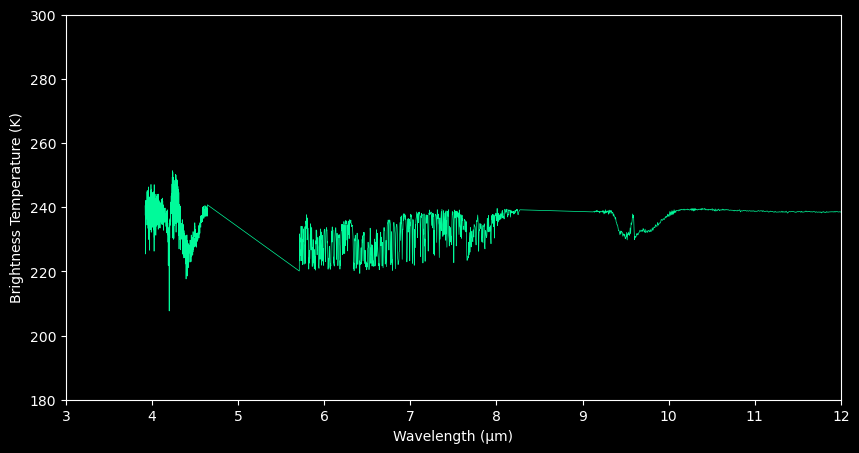

In [11]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('black')

ax.plot(wl_1, Tb_1, 
        color="#00FA9A", 
        linewidth=0.5)
ax.set_xlim((3,12))
ax.set_ylim((180,300))

ax.set_xlabel("Wavelength (μm)")
ax.set_ylabel("Brightness Temperature (K)")

plt.savefig(f"plots/{today_date_str}_cris_spectra.png", dpi=200, bbox_inches='tight')
plt.show()